In [153]:
import pandas as pd 
import numpy as np

In [154]:
gov = pd.read_csv('Data/hpi master.csv')

In [155]:
blacklist = ['East North Central Division', 'East South Central Division',
       'Middle Atlantic Division', 'Mountain Division',
       'New England Division', 'Pacific Division',
       'South Atlantic Division', 'West North Central Division',
       'West South Central Division', 'United States','Alaska', 'Alabama', 'Arkansas', 'Arizona', 'California',
       'Colorado', 'Connecticut', 'District of Columbia', 'Delaware',
       'Florida', 'Georgia', 'Hawaii', 'Iowa', 'Idaho', 'Illinois',
       'Indiana', 'Kansas', 'Kentucky', 'Louisiana', 'Massachusetts',
       'Maryland', 'Maine', 'Michigan', 'Minnesota', 'Missouri',
       'Mississippi', 'Montana', 'North Carolina', 'North Dakota',
       'Nebraska', 'New Hampshire', 'New Jersey', 'New Mexico', 'Nevada',
       'New York', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Virginia', 'Vermont', 'Washington', 'Wisconsin',
       'West Virginia', 'Wyoming', 'Puerto Rico']
gov = gov[(gov['yr'] >= 2017) & (gov['yr'] <= 2019)]
gov = gov[~gov['place_name'].isin(blacklist)]

In [156]:
# First, let's create a list from your data
import re
import pandas as pd

county_filter = gov['place_name'].str.contains('County', case=False)

# Alternative approach - look for entries that have a simpler format (City, STATE)
# This might need refinement based on your specific data
simple_format_filter = ~gov['place_name'].str.contains('-|\/|\(MSAD\)|\(', regex=True)

# Combine filters if needed
gov_counties = gov[simple_format_filter]

# Now extract county and state
# For pattern like "Albany, GA"
def extract_county_state(place_name):
    # Basic pattern matching for "Name, STATE" format
    match = re.match(r'([^,]+),\s*([A-Z]{2})', place_name)
    if match:
        county = match.group(1).strip()
        state = match.group(2).strip()
        return county, state
    else:
        return place_name, None  # Return original if no match

# Apply the function to create new columns
gov_counties[['county', 'state']] = pd.DataFrame(
    gov_counties['place_name'].apply(extract_county_state).tolist(),
    index=gov_counties.index
)

# Remove rows where state extraction failed
gov_counties = gov_counties.dropna(subset=['state'])

/var/folders/m2/kj3jnz6d03z1s37zqkzg8xbm0000gn/T/ipykernel_78881/1546588061.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gov_counties[['county', 'state']] = pd.DataFrame(
/var/folders/m2/kj3jnz6d03z1s37zqkzg8xbm0000gn/T/ipykernel_78881/1546588061.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gov_counties[['county', 'state']] = pd.DataFrame(


In [157]:
gov_counties = gov_counties[gov_counties['period'] == 1]

In [158]:
drop = ['hpi_type','hpi_flavor','frequency','level','index_sa','place_name']
gov_counties = gov_counties.drop(columns = drop)

In [159]:
# Pivot the gov_counties table with years as columns
rotated_gov = gov_counties.pivot_table(
    index=['county', 'state', 'period', 'place_id'], 
    columns='yr',
    values='index_nsa',
    aggfunc='mean'  # Handles any potential duplicates
)

# Reset index to convert index back to regular columns
rotated_gov = rotated_gov.reset_index()

# Remove the name from the columns level
rotated_gov.columns.name = None

# Group by state and calculate the mean, ignoring NaN values
rotated_gov_group = rotated_gov.groupby('state').mean(numeric_only=True)
rotated_gov_group['change'] = (rotated_gov_group[2019] - rotated_gov_group[2017]) / rotated_gov_group[2017] * 100

In [160]:
zillow = pd.read_csv('Data/zillow county.csv')
zillow_2017_cols = [col for col in zillow.columns if '2017' in str(col)]
zillow_2019_cols = [col for col in zillow.columns if '2019' in str(col)]

# Step 2: Calculate the average of 2017 and 2019 columns for each row
zillow['zillow_2017'] = zillow[zillow_2017_cols].mean(axis=1)
zillow['zillow_2019'] = zillow[zillow_2019_cols].mean(axis=1)

date_columns = [col for col in zillow.columns if '-' in str(col)]

# Step 2: Drop those date columns
zillow_filtered = zillow.drop(columns=date_columns)

In [161]:
state_grouped = zillow_filtered.groupby('State').mean()

/var/folders/m2/kj3jnz6d03z1s37zqkzg8xbm0000gn/T/ipykernel_78881/1140043337.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  state_grouped = zillow_filtered.groupby('State').mean()


In [162]:
state_grouped['difference'] = (state_grouped['zillow_2019'] - state_grouped['zillow_2017']) / state_grouped['zillow_2017'] * 100

In [163]:
sbs = pd.concat([state_grouped[['difference']],rotated_gov_group['change']],axis = 1)
sbs = sbs.rename(columns = {'difference':'Zillow','change':'Government'})

In [164]:
sbs

,Zillow,Government
AK,9.116264,1.592265
AL,8.604594,7.212903
AR,7.433585,7.010125
AZ,14.687825,12.015689
CA,11.891917,13.459803
CO,15.054495,16.990397
CT,3.531942,NaN
DC,8.275832,NaN
DE,6.436983,3.348326
FL,13.510276,16.244247


In [182]:
rotated_gov['change'] = (rotated_gov[2019] - rotated_gov[2017])/rotated_gov[2017] *100

In [184]:
rotated_gov

,county,state,period,place_id,2017,2018,2019,change
0,Abilene,TX,1,10180,200.390,210.04,219.450,9.511453
1,Akron,OH,1,10420,156.985,165.95,172.775,10.058286
2,Albany,GA,1,10500,150.330,155.33,156.550,4.137564
3,Albuquerque,NM,1,10740,190.610,199.48,207.365,8.790200
4,Alexandria,LA,1,10780,200.620,208.11,206.840,3.100389
...,...,...,...,...,...,...,...,...
212,Williamsport,PA,1,48700,190.220,198.65,199.230,4.736621
213,Wilmington,NC,1,48900,202.190,217.34,232.090,14.788071
214,Yakima,WA,1,49420,179.690,196.99,216.220,20.329456
215,Yuba City,CA,1,49700,214.510,233.52,248.040,15.630973


Min value: -4.587761964811154, Max value: 22.06692648837522
Using two-slope normalization


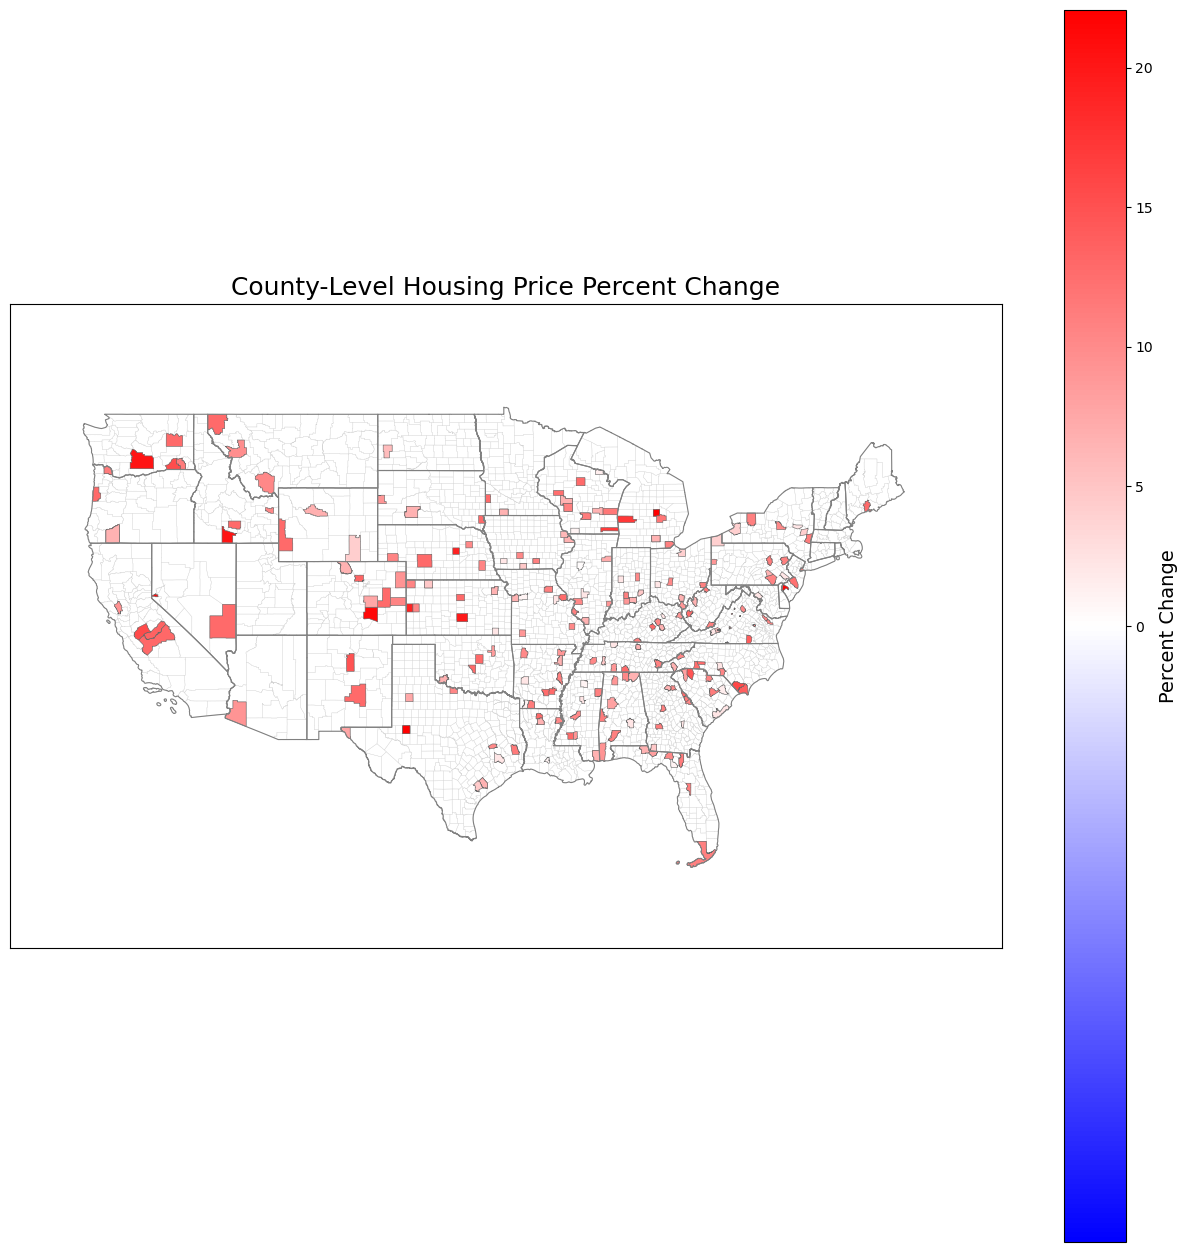

In [208]:
import matplotlib.pyplot as plt
import geopandas as gpd
import os
from matplotlib.colors import Normalize
import numpy as np

# Read the county shapefile
county = gpd.read_file(os.getcwd() + '/tl_2019_us_county')

# Create a US states layer for outlines
states = county.dissolve(by='STATEFP')

# Merge with your rotated_gov DataFrame for data
map_data = county.merge(rotated_gov, left_on='NAME', right_on='county')

# Before creating the normalization, check the min and max values
min_val = map_data["change"].min()
max_val = map_data["change"].max()
print(f"Min value: {min_val}, Max value: {max_val}")

# Set up the figure and axis
fig, ax = plt.subplots(1, figsize=(16, 16))

# First plot all counties with no fill to establish the complete US outline
county.plot(ax=ax, color='none', edgecolor='lightgray', linewidth=0.2)

# Then plot the state boundaries to get clearer state outlines
states.boundary.plot(ax=ax, edgecolor='gray', linewidth=0.8)

# Define normalization based on the actual data range
if min_val >= 0:
    # Use a standard colormap without the two-slope normalization
    norm = Normalize(vmin=min_val, vmax=max_val)
    cmap = "viridis"  # or any other colormap you prefer for single direction data
    print("Using standard normalization since all values are positive")
else:
    # We can safely use TwoSlopeNorm since we have negative and positive values
    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=min_val, vcenter=0, vmax=max_val)
    cmap = "bwr"
    print("Using two-slope normalization")

# Now plot the data counties on top with colored fill
map_data.plot(column="change", 
              cmap=cmap, 
              linewidth=0.4, 
              ax=ax, 
              edgecolor=".4", 
              legend=False, 
              norm=norm)

# Set x and y limits to focus on mainland US
ax.set_xlim(-130, -60)
ax.set_ylim(20, 55)

# Add title
ax.set_title('County-Level Housing Price Percent Change', fontsize=18)

# Create the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []  # Empty array for the ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Percent Change', fontsize=14)

# Remove axis ticks and labels for a cleaner map
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

# Create output path in Images folder
os.makedirs('Images', exist_ok=True)
output_path = os.path.join('Images', 'Heat_Map_Gov_PPI.png')

# Save the plot with high resolution
plt.savefig(output_path, 
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.1)

plt.show()
plt.close()